In [1]:
# Define get_pauli_sum_op directly in notebook to ensure correct format handling
from qiskit.quantum_info import PauliList, SparsePauliOp

def get_pauli_sum_op(H):
    """Convert Hamiltonian list to SparsePauliOp.
    
    Handles both formats:
    - [(pauli_string, coefficient), ...]  e.g., [('IZZ', -1), ...]
    - [(coefficient, pauli_string), ...]  e.g., [(-1, 'IZZ'), ...]
    """
    # Detect format by checking if first element of first tuple is a string
    if isinstance(H[0][0], str):
        # Format: (pauli_string, coefficient)
        pauli_strings = [term[0] for term in H]
        coeffs = [term[1] for term in H]
    else:
        # Format: (coefficient, pauli_string)
        pauli_strings = [term[1] for term in H]
        coeffs = [term[0] for term in H]
    
    pauli_list = PauliList(pauli_strings)
    return SparsePauliOp(pauli_list, coeffs=coeffs)

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import qiskit
import glob
import pickle
import scipy.linalg as linalg

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, PauliList, Operator, Choi, diamond_norm, process_fidelity, SuperOp
from qiskit import QuantumCircuit
from qiskit.synthesis import SuzukiTrotter
from qiskit.circuit.library import PauliEvolutionGate

import dqs
from dqs.run_process_fidelity_simulation import fidelity_over_r
from dqs.run_process_fidelity_simulation import get_exact_unitary

matplotlib.rc('xtick', labelsize=15)
matplotlib.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"

In [3]:
def get_exact_unitary_v2(H, t):
    """Compute exact unitary U = exp(-i * H * t) for a Pauli sum Hamiltonian.
    
    Parameters
    ----------
    H : list
        Hamiltonian in format [(pauli_string, coefficient), ...]
        e.g., [('IZZ', -1), ('ZZI', -1), ('ZIZ', -1), ...]
    t : float
        Evolution time
        
    Returns
    -------
    U : np.ndarray
        Unitary matrix of shape (2^n, 2^n) where n is number of qubits
    """
    # Convert Hamiltonian to matrix and exponentiate
    matrix = get_pauli_sum_op(H).to_matrix()
    return linalg.expm(-1j * matrix * t)

In [4]:
def time_simulation(Hfunc, init_state, meas_op, tstart=0, tend=4, tstep=0.01):
    """Simulate time evolution with exact Hamiltonian.
    
    Parameters
    ----------
    Hfunc : callable
        Function that returns Hamiltonian at time t: H = Hfunc(t)
        Hamiltonian format: [(pauli_string, coefficient), ...]
    init_state : Statevector
        Initial quantum state
    meas_op : SparsePauliOp
        Measurement operator
    tstart, tend, tstep : float
        Time range and step size
        
    Returns
    -------
    expectations : list
        Expectation values at each time step
    time : np.ndarray
        Time array
    """
    expectations = []
    time = np.arange(tstart, tend, tstep)
    for t in time:
        # Get Hamiltonian at time t
        curH = Hfunc(t)
        # Compute exact unitary
        evolution_unitary = get_exact_unitary_v2(curH, t)
        # Evolve state and measure
        final_state = init_state.evolve(evolution_unitary)
        expectations.append(final_state.expectation_value(meas_op).real)
    return expectations, time

def trotter_time_simulation(dqs_obj, Hfunc, init_state, meas_op, tstart=0, tend=4, tstep=0.01, r=1):
    """Simulate time evolution with DQS Trotter circuit.
    
    Parameters
    ----------
    dqs_obj : Dynamics
        DQS Dynamics object (already initialized and sorted)
    Hfunc : callable
        Function that returns Hamiltonian at time t: H = Hfunc(t)
        Hamiltonian format: [(pauli_string, coefficient), ...]
    init_state : Statevector
        Initial quantum state
    meas_op : SparsePauliOp
        Measurement operator
    tstart, tend, tstep : float
        Time range and step size
    r : int
        Trotter repetitions
        
    Returns
    -------
    expectations : list
        Expectation values at each time step
    time : np.ndarray
        Time array
    process_fidelity : list
        Process fidelity at each time step
    diamond_distance : list
        Diamond distance at each time step
    """
    expectations = []
    process_fidelity = []
    diamond_distance = []
    time = np.arange(tstart, tend, tstep)
    for t in time:
        # Get Hamiltonian at time t (format: [(pauli_string, coefficient), ...])
        curH = Hfunc(t)
        # Update DQS object with current Hamiltonian coefficients
        # DQS expects format: [(coefficient, pauli_string), ...]
        dqs_obj.update_coefficients([(term[1], term[0]) for term in curH])
        # Generate circuit
        dqs_obj.gen_circuit(t=t, r=r)
        # Get circuit unitary
        evolution_unitary = dqs_obj.getCircuitUnitary()
        # Evolve state and measure
        final_state = init_state.evolve(evolution_unitary)
        expectations.append(final_state.expectation_value(meas_op).real)
        
        # Compute exact unitary for comparison (curH is in [(pauli_string, coef), ...] format)
        exact_unitary = get_exact_unitary_v2(curH, t)
        process_fidelity.append(dqs_obj.processFidelity(exact_unitary, evolution_unitary))
        diamond_distance.append(dqs_obj.diamondNorm(exact_unitary, evolution_unitary))
    return expectations, time, process_fidelity, diamond_distance

# Trotterization approximations to Ising Model

In [5]:
nq = 3

def hamiltonian(t):
    omega = np.pi
    epsilon = -1
    interaction = -1
    factor = epsilon * np.cos(omega * t)
    return [('IZZ', interaction), ('ZZI', interaction), ('ZIZ', interaction), ('IIX', factor), ('XII', factor), ('IXI', factor)]

init_circ = qiskit.QuantumCircuit(nq)
#init_circ.x(1)
#init_circ.cx(1,2)
init_state = Statevector.from_instruction(init_circ)
print(init_circ)

meas_op = get_pauli_sum_op([('ZII', 1), ('IZI', 1), ('IIZ', 1)])

print('Exact results...')
exact_expectations, times = time_simulation(hamiltonian, init_state, meas_op, tend=0.5*np.pi, tstep=0.01)

results = [('Exact', exact_expectations, times, [])]
for sort_type in ['lex', 'mag', 'mc_tsp', 'rand']:
    print(f'{sort_type.upper()} results...')
    dqs_obj = dqs.quantum_dynamics.Dynamics([(term[1], term[0]) for term in hamiltonian(1)])
    dqs_obj.sort_hamiltonian(sort_type)
    expectations, time, process_fidelity, diamond_distance = trotter_time_simulation(dqs_obj, hamiltonian, init_state, meas_op, tend=0.5*np.pi, tstep=0.01)
    results.append((sort_type.upper(), expectations, time, process_fidelity, diamond_distance))
print('done')

     
q_0: 
     
q_1: 
     
q_2: 
     
Exact results...


LEX results...


QiskitError: 'Cannot add shapes with different total left dimension 2 != 8'

ValueError: not enough values to unpack (expected 5, got 4)

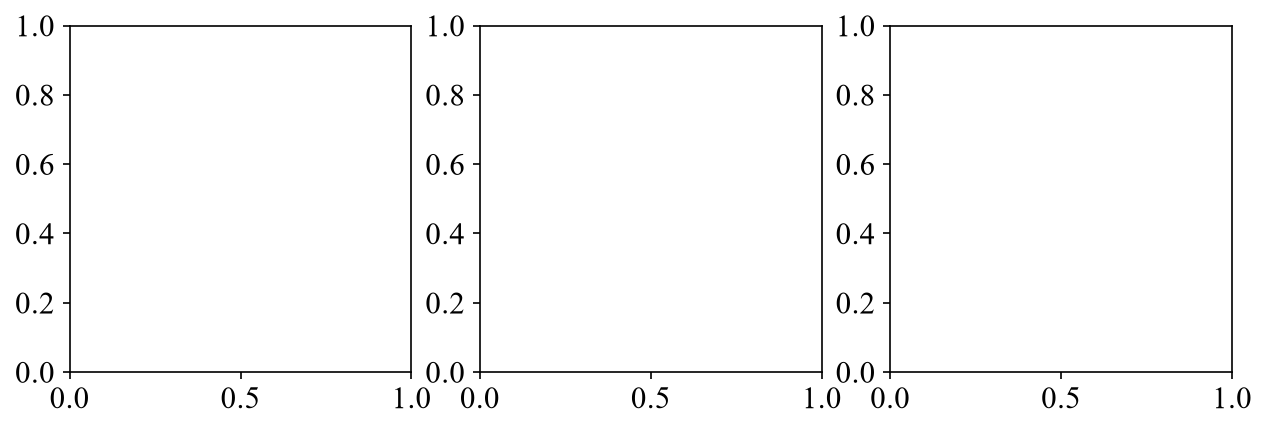

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, dpi=150, figsize=[10,3])
exact_results = results[0][1]
for i, (label, expectations, time, pfids, diamond_dists) in enumerate(results):
    offset = 0.01 * i * 0
    ax[0].plot(time, [expval / nq + offset for expval in expectations], label=label)
    ax[1].plot(time, [(approx - exact)/ nq for approx, exact in zip(expectations, exact_results)], label=label)
    if len(pfids) == len(time):
        ax[2].plot(time, pfids, label=label)
ax[0].legend()
ax[0].set_ylabel('Average magnetization, <Z> / N')
ax[0].set_xlabel('Time')
ax[1].set_ylabel('Error from exact')
ax[1].set_xlabel('Time')

In [6]:
nq = 4

random_hamiltonian = dqs.hamiltonians.random_H(nq, 50, binary=False)
print(random_hamiltonian)

def hamiltonian(t):
    return [(term[1], term[0]) for term in random_hamiltonian]

init_circ = qiskit.QuantumCircuit(nq)
#init_circ.x(1)
#init_circ.cx(1,2)
init_state = qiskit.quantum_info.Statevector.from_instruction(init_circ)
print(init_circ)

meas_op = get_pauli_sum_op([('ZIII', 1), ('IZII', 1), ('IIZI', 1), ('IIIZ', 1)])

print('Exact results...')
exact_expectations, times = time_simulation(hamiltonian, init_state, meas_op, tend=1, tstep=0.02)

results = [('Exact', exact_expectations, times, [], [])]
for sort_type in ['lex', 'mag', 'mc_tsp', 'rand', 'depletegroups']:
    print(f'{sort_type.upper()} results...')
    dqs_obj = dqs.quantum_dynamics.Dynamics([(term[1], term[0]) for term in hamiltonian(1)])
    dqs_obj.sort_hamiltonian(sort_type)
    simresult = trotter_time_simulation(dqs_obj, hamiltonian, init_state, meas_op, tend=1, tstep=0.02)
    results.append((sort_type.upper(), *simresult))
print('done')

[(np.float64(0.6504680504513568), 'IXZX'), (np.float64(-0.3744691228717134), 'XZXX'), (np.float64(0.4250318257454383), 'YYYI'), (np.float64(0.22291371813763894), 'YXYZ'), (np.float64(0.36154235142076674), 'YXZZ'), (np.float64(-0.51980771739662), 'YZYX'), (np.float64(-0.4492219054290605), 'XXYY'), (np.float64(-0.6816450119967228), 'ZZIX'), (np.float64(-0.602455544668261), 'YXYY'), (np.float64(-0.2952989526779686), 'XIXI'), (np.float64(0.6850544657298874), 'IXYZ'), (np.float64(0.32772793170836834), 'ZYII'), (np.float64(-0.888301605100494), 'ZXIZ'), (np.float64(-0.8176549320663752), 'ZZII'), (np.float64(0.40589036633532205), 'ZZYI'), (np.float64(0.37923696783042504), 'IXXZ'), (np.float64(-0.5752978095448823), 'YXXY'), (np.float64(0.29711462445382975), 'XYZX'), (np.float64(0.7241523422295688), 'XIZI'), (np.float64(-0.9120939377330836), 'IYYX'), (np.float64(0.6239831784498687), 'XXZI'), (np.float64(-0.894648267471699), 'ZXZZ'), (np.float64(0.6191197313133194), 'ZXIY'), (np.float64(-0.217904

QiskitError: 'Cannot add shapes with different total left dimension 4 != 16'

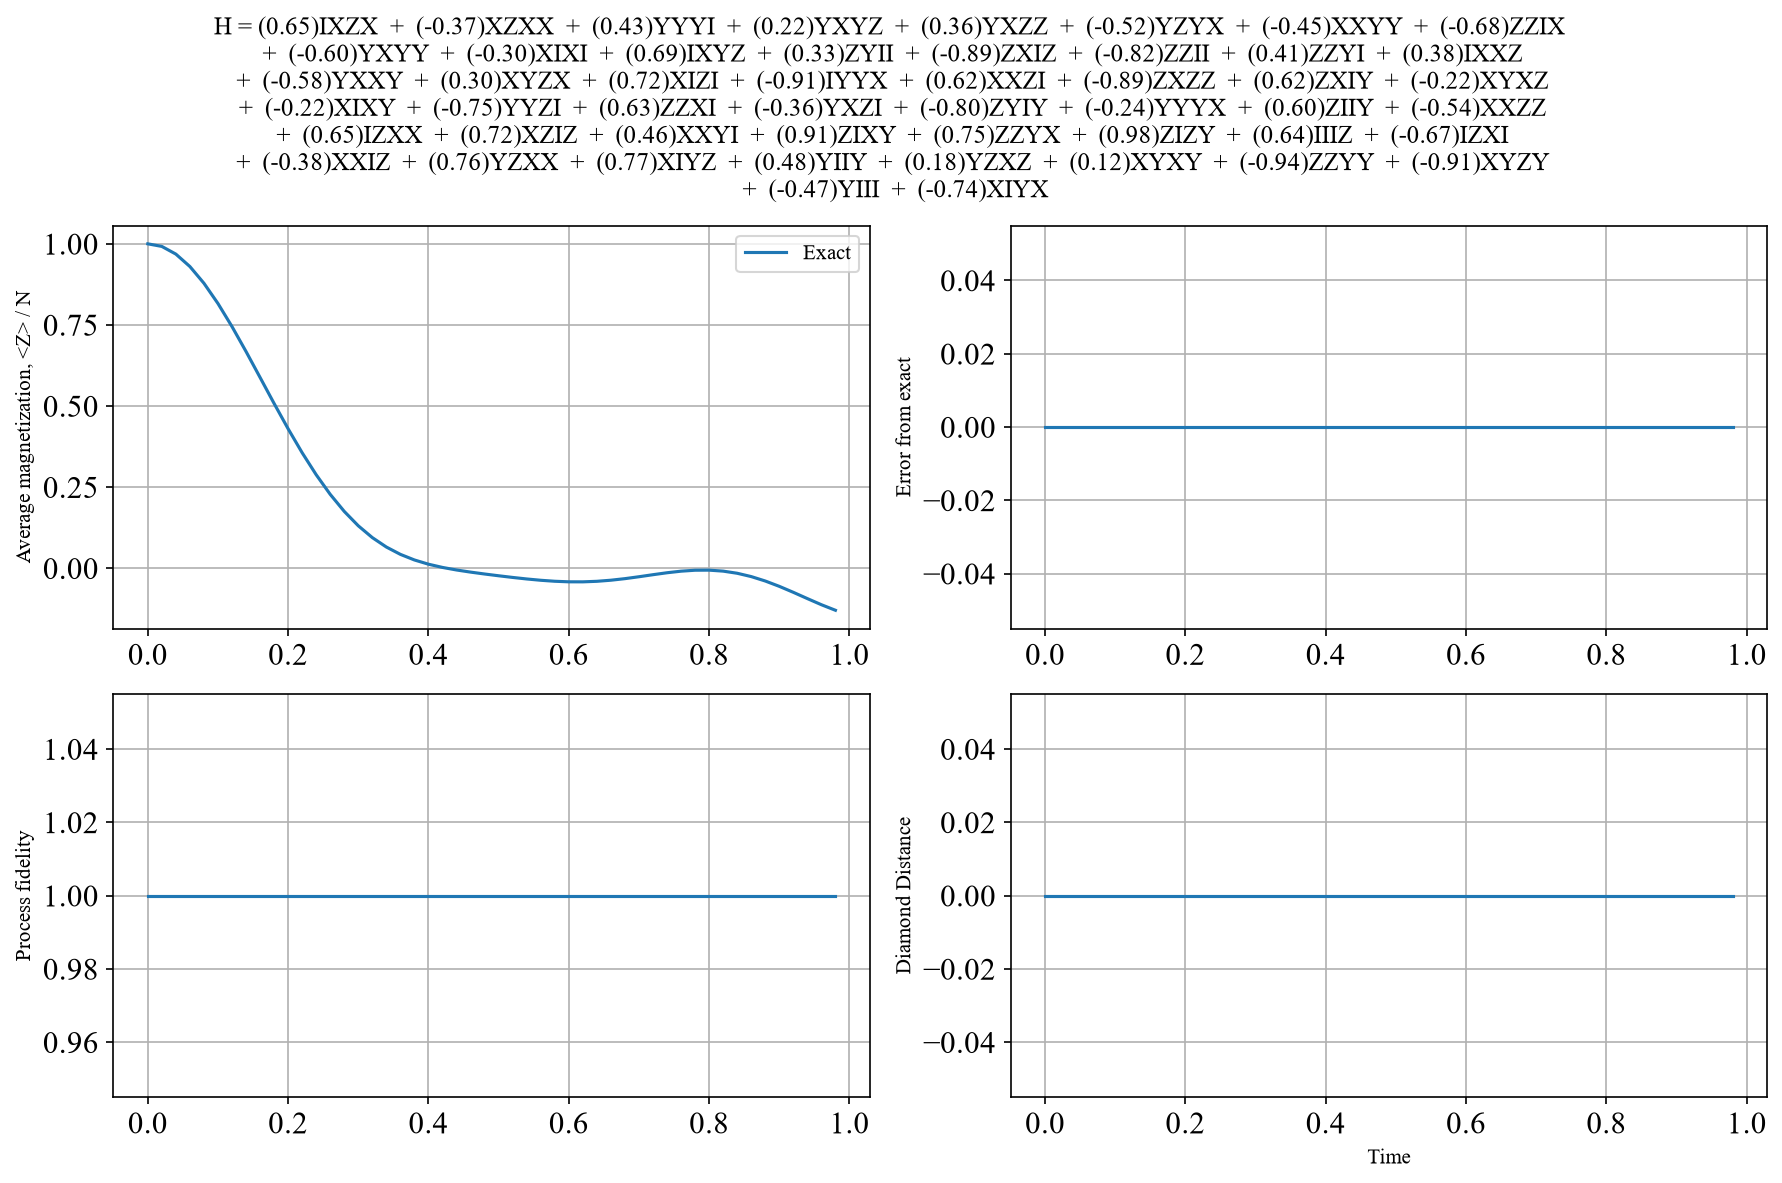

In [7]:
fig, ax = plt.subplots(nrows=2, ncols=2, dpi=150, figsize=[12,8])
exact_results = results[0][1]
for i, (label, expectations, time, pfids, diamond_dists) in enumerate(results):
    offset = 0.01 * i * 0
    ax[0][0].plot(time, [expval / nq + offset for expval in expectations], label=label)
    ax[0][1].plot(time, [(approx - exact)/ nq for approx, exact in zip(expectations, exact_results)], label=label)
    if label == 'Exact':
        pfids = [1]*len(time)
        diamond_dists = [0]*len(time)
    ax[1][0].plot(time, pfids, label=label)
    ax[1][1].plot(time, diamond_dists, label=label)
ax[0][0].legend()
ax[0][0].set_ylabel('Average magnetization, <Z> / N')
ax[0][1].set_ylabel('Error from exact')
ax[1][0].set_ylabel('Process fidelity')
ax[1][1].set_ylabel('Diamond Distance')
for i, row in enumerate(ax):
    for axis in row:
        axis.grid()
    if i == 1:
        axis.set_xlabel('Time')
hstr = dqs.hamiltonians.get_H_str([(term[1], term[0]) for term in hamiltonian(0)], sigfigs=2)
harray = hstr.split('+')
if len(harray) > 8:
    hstr = harray[0]
    i = 1
    for term in harray[1:]:
        hstr += f' + {term}'
        i += 1
        if i >= 8:
            hstr += '\n'
            i = 0
fig.suptitle('H = ' + hstr)
plt.tight_layout()
#plt.savefig('figures/random-binary-hamiltonian_2.pdf')

In [8]:
def reach_epsilon(t, epsilon, dqs_obj, r_limit=10):
    Uexact = get_exact_unitary(dqs_obj._getH_without_groups(), t)
    cur_epsilon = 100
    r = 0
    while cur_epsilon > epsilon and r < r_limit:
        r += 1
        dqs_obj.gen_circuit(t=t, r=r)
        Uapprox = dqs_obj.getCircuitUnitary()
        cur_epsilon = dqs_obj.diamondNorm(Uexact, Uapprox)
    
    if r >= r_limit:
        print(f"Unable to achieve epsilon <= {epsilon} with r <= {r_limit}")
        return -1, r, -1
    
    cnot_cost = dqs_obj.total_cnot_count(r=r)
    
    return cur_epsilon, r, cnot_cost

In [9]:
num_qubits = 4
num_terms = 20
epsilon_limit = 0.2

hamiltonian = dqs.hamiltonians.random_H(num_qubits, num_terms, binary=True)
print(hamiltonian)

results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
for sort_type in results.keys():
    print(f'{sort_type.upper()} results...')
    for t in np.arange(0, 1.1, 0.1):
        dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
        dqs_obj.sort_hamiltonian(sort_type)
        simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
        if simresult[0] == -1:
            break
        results[sort_type].append((t, *simresult))
print('done')

[(np.int64(1), 'XYZZ'), (np.int64(-1), 'XYXZ'), (np.int64(-1), 'XYIZ'), (np.int64(-1), 'YYYI'), (np.int64(1), 'XIZY'), (np.int64(1), 'YIIY'), (np.int64(-1), 'YIIX'), (np.int64(1), 'ZZZZ'), (np.int64(-1), 'XZXI'), (np.int64(1), 'XXYI'), (np.int64(-1), 'IZIX'), (np.int64(-1), 'YIYX'), (np.int64(-1), 'ZZXZ'), (np.int64(-1), 'IZIZ'), (np.int64(-1), 'XIXX'), (np.int64(1), 'XZZY'), (np.int64(-1), 'YXZY'), (np.int64(1), 'XXIY'), (np.int64(1), 'IYIY'), (np.int64(1), 'YYZZ')]
LEX results...


TypeError: get_exact_unitary() takes 1 positional argument but 2 were given

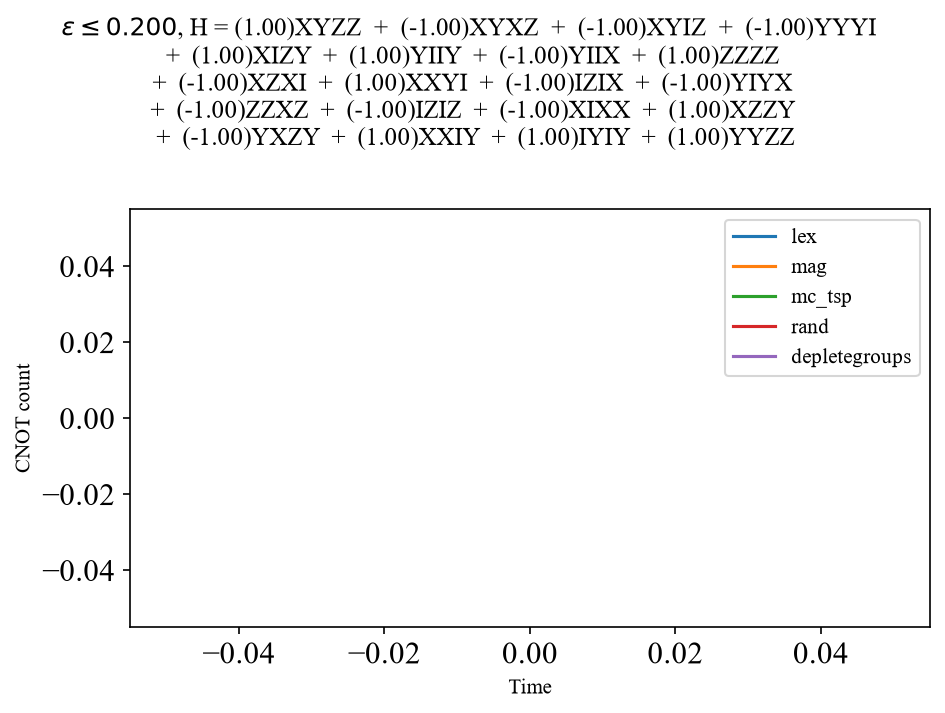

In [10]:
fig, ax = plt.subplots(dpi=150)

for label, result in results.items():
    time, diamond_dist, r_needed, gate_count = [], [], [], []
    for val in result:
        if val[1] < 0:
            break
        time.append(val[0])
        diamond_dist.append(val[1])
        r_needed.append(val[2])
        gate_count.append(val[3])
    
    ax.plot(time, gate_count, label=label)

ax.legend()
ax.set_ylabel('CNOT count')
ax.set_xlabel('Time')
hstr = dqs.hamiltonians.get_H_str(hamiltonian, sigfigs=2)
harray = hstr.split('+')
if len(harray) > 4:
    hstr = harray[0]
    i = 1
    for term in harray[1:]:
        hstr += f' + {term}'
        i += 1
        if i >= 4:
            hstr += '\n'
            i = 0
fig.suptitle(r'$\epsilon \leq {:.3f}$, H = {}'.format(epsilon_limit, hstr))
plt.tight_layout()
plt.show()
plt.close()

In [11]:
epsilon_limit = 0.2
molecule = 'Methylamine_sto-3g_JW_NIST_AS2'
hamiltonian = dqs.quantum_dynamics.Dynamics(f'dqs/hamiltonians/{molecule}.txt')._getH_without_groups()
print(hamiltonian)

results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
for sort_type in results.keys():
    print(f'{sort_type.upper()} results...')
    for t in np.arange(0, 1.1, 0.1):
        dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
        dqs_obj.sort_hamiltonian(sort_type)
        simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
        if simresult[0] == -1:
            break
        results[sort_type].append((t, *simresult))
print('done')

[(-1.8577463854703422e-07, 'YYXX'), (1.8577463854703422e-07, 'XYYX'), (-0.0005318575142158455, 'IXZX'), (0.00011851141427133297, 'ZXZX'), (0.00019351067740563894, 'IXIX'), (1.8577463854703422e-07, 'YXXY'), (-1.8577463854703422e-07, 'XXYY'), (-0.0005318575142158455, 'IYZY'), (0.00011851141427133297, 'ZYZY'), (0.00019351067740563894, 'IYIY'), (3.3017623766914292, 'IIIZ'), (0.00019351067740563894, 'XZXZ'), (0.00019351067740563894, 'YZYZ'), (1.0317057101813696, 'IIZZ'), (0.09031383437777553, 'IZIZ'), (0.09031402015241408, 'ZIIZ'), (-0.0005318575142158454, 'XZXI'), (0.00011851141427133298, 'XIXI'), (-0.0005318575142158454, 'YZYI'), (0.00011851141427133298, 'YIYI'), (3.3017623766914292, 'IIZI'), (0.09031402015241408, 'IZZI'), (0.09031383437777553, 'ZIZI'), (1.0528741030160065, 'IZII'), (0.8754243524090393, 'ZZII'), (1.0528741030160065, 'ZIII')]
LEX results...


TypeError: get_exact_unitary() takes 1 positional argument but 2 were given

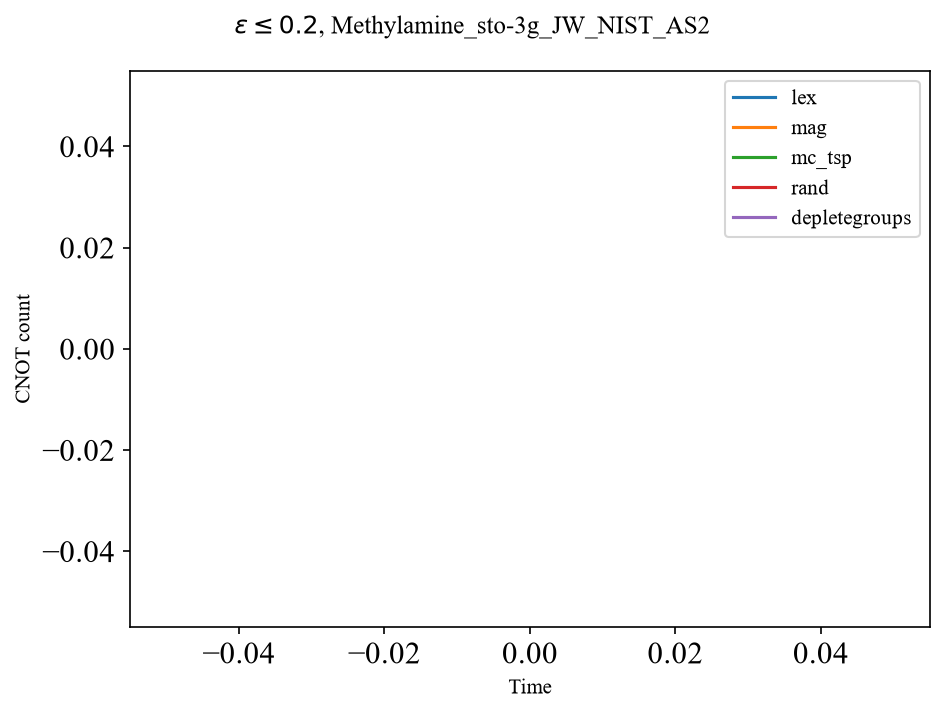

In [12]:
fig, ax = plt.subplots(dpi=150)

for label, result in results.items():
    time, diamond_dist, r_needed, gate_count = [], [], [], []
    for val in result:
        if val[1] < 0:
            break
        time.append(val[0])
        diamond_dist.append(val[1])
        r_needed.append(val[2])
        gate_count.append(val[3])
    
    ax.plot(time, gate_count, label=label)

ax.legend()
ax.set_ylabel('CNOT count')
ax.set_xlabel('Time')
fig.suptitle(r'$\epsilon \leq {}$, {}'.format(epsilon_limit, molecule))
plt.tight_layout()
plt.show()
plt.close()

In [13]:
glob.glob('dqs/hamiltonians/*AS2.txt')

['dqs/hamiltonians\\1-propanol_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\1-propanol_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians\\Ammonia_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\Ammonia_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians\\Ammonium_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\Ammonium_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians\\BerylliumHydride_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\BerylliumHydride_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians\\CarbonDioxide_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\CarbonDioxide_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians\\CarbonMonoxide_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\CarbonMonoxide_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians\\Cl2_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\Cl2_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians\\Dimethylamine_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\Dimethylamine_sto-3g_JW_NIST_AS2.txt',
 'dqs/hamiltonians\\Ethanal_sto-3g_BK_NIST_AS2.txt',
 'dqs/hamiltonians\\Ethanal_sto-3g_JW_NIST_

In [14]:
epsilon_limit = 0.2
for fn in glob.glob('dqs/hamiltonians/*AS2.txt'):
    molecule = fn.split('/')[-1][:-4]
    hamiltonian = dqs.quantum_dynamics.Dynamics(fn)._getH_without_groups()
    print(molecule)

    results = {'lex': [], 'mag': [], 'mc_tsp': [], 'rand': [], 'depletegroups': []}
    for sort_type in results.keys():
        print(f'{sort_type.upper()} results...')
        for t in np.arange(0, 1.1, 0.1):
            dqs_obj = dqs.quantum_dynamics.Dynamics(hamiltonian)
            dqs_obj.sort_hamiltonian(sort_type)
            simresult = reach_epsilon(t, epsilon_limit, dqs_obj, r_limit=12)
            if simresult[0] == -1:
                break
            results[sort_type].append((t, *simresult))
    print('done')

    fig, ax = plt.subplots(dpi=150)

    for label, result in results.items():
        time, diamond_dist, r_needed, gate_count = [], [], [], []
        for val in result:
            if val[1] < 0:
                break
            time.append(val[0])
            diamond_dist.append(val[1])
            r_needed.append(val[2])
            gate_count.append(val[3])

        ax.plot(time, gate_count, label=label)

    ax.legend()
    ax.set_ylabel('CNOT count')
    ax.set_xlabel('Time')
    ax.set_title(r'$\epsilon \leq {}$, {}'.format(epsilon_limit, molecule))
    plt.tight_layout()
    plt.savefig(f'figures/molecular_hamiltonians_epsilon_limit/{molecule}_epsilon{epsilon_limit}.pdf')
    plt.close()

hamiltonians\1-propanol_sto-3g_BK_NIST_AS2
LEX results...


TypeError: get_exact_unitary() takes 1 positional argument but 2 were given

# Plot Gate Cost Simulations

In [ ]:
pickles = glob.glob('dqs/benchmark_results/gate_cost_simulation/4qubit_epsilon0.1/*pickle')
print(len(pickles))

In [ ]:
all_data = {key: [] for key in ['lex', 'mag', 'mc_tsp', 'rand', 'depletegroups']}
for pklfile in pickles:
    with open(pklfile, 'rb') as pf:
        result = pickle.load(pf)
        for key in result.keys():
            all_data[key].append(result[key])

In [ ]:
all_data

In [ ]:
fig, ax = plt.subplots(dpi=150)

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
label_dict = {'lex': 'LEX', 'mag': 'MAG', 'mc_tsp': 'MCTSP (this work)', 'rand': 'Random', 'depletegroups': 'DepleteGroups'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(cnot_dict[t]) for t in times]
    stdevs = [np.std(cnot_dict[t]) for t in times]
    maxs = [np.max(cnot_dict[t]) for t in times]
    mins = [np.min(cnot_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=label_dict[sort_type], fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]
    #y1 = maxs
    #y2 = mins
    #ax.fill_between(times, y1, y2, alpha=0.1)
ax.legend(fontsize=12)
ax.grid()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel('CNOTs', fontsize=15)
ax.set_title(r'Average gate cost', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_cnot.pdf')

In [ ]:
for key in plotted_vals.keys():
    if key == 'mc_tsp':
        continue
    
    percent_reducs = [(other_val - mctsp_val) / other_val for other_val, mctsp_val in zip(plotted_vals[key], plotted_vals['mc_tsp'])]
    print(f'Average reduction in gate count between {key} -> mc_tsp = {np.mean(percent_reducs) * 100:.3f}%')

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=[6,3])

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
label_dict = {'lex': 'LEX', 'mag': 'MAG', 'mc_tsp': 'MCTSP', 'rand': 'Random', 'depletegroups': 'DepleteGroups'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(epsilon_dict[t]) for t in times]
    stdevs = [np.std(epsilon_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=label_dict[sort_type], fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]

#ax.axhline(y=0.1, color='k', ls='--')
ax.grid()
#ax.legend()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel(r'$\epsilon$', fontsize=17)
ax.set_title(r'Average accuracy', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_accuracy.pdf')    

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=[6,3])

plotted_vals = {}
reclength = 7
color_dict = {'lex': 'tab:green', 'mag': 'tab:orange', 'mc_tsp': 'tab:cyan', 'rand': 'tab:red', 'depletegroups': 'tab:purple'}
for sort_type, values in all_data.items():
    times = []
    for run in values:
        if len(run) >= reclength:
            for i, point in enumerate(run):
                if i < reclength:
                    times.append(point[0])
    times = sorted(list(set(times)))
    
    epsilon_dict = {t: [] for t in times}
    rval_dict = {t: [] for t in times}
    cnot_dict = {t: [] for t in times}
    for run in values:
        if len(run) >= reclength:
            for (t, epsilon, r, cnot_cost) in run:
                if t in times:
                    epsilon_dict[t].append(epsilon)
                    rval_dict[t].append(r)
                    cnot_dict[t].append(cnot_cost)
    
    # Plot cnot cost
    #for key, val in cnot_dict.items():
    #    print(f'{len(val)} data points at t = {key:.2f}')
    
    means = [np.mean(rval_dict[t]) for t in times]
    stdevs = [np.std(rval_dict[t]) for t in times]
    
    plotted_vals[sort_type] = means
    
    ax.errorbar(times, means, label=sort_type, fmt='-o', ms=4, color=color_dict[sort_type])
    y1 = [m+s for m, s in zip(means, stdevs)]
    y2 = [max(m-s, 0) for m, s in zip(means, stdevs)]

#ax.legend()
ax.grid()
ax.set_xlabel('Time', fontsize=15)
ax.set_ylabel('Repetitions, r', fontsize=15)
ax.set_title(r'Average Trotter number', fontsize=15)
plt.tight_layout()
plt.savefig('figures/average_r.pdf')

In [ ]:
molecules = ['Ethene_sto-3g_BK_NIST_AS2.txt', 'Cl2_sto-3g_JW_NIST_AS2.txt', 'Ethyne_sto-3g_JW_NIST_AS2.txt',
             'F2_sto-3g_JW_NIST_AS2.txt', 'N2_sto-3g_JW_NIST_AS2.txt', 'O2_sto-3g_BK_NIST_triplet_AS2.txt']
t = 1
for molecule in molecules:
    print(molecule)
    dqs_obj = dqs.quantum_dynamics.Dynamics('dqs/hamiltonians/' + molecule)
    Uexact = get_exact_unitary(dqs_obj._getH_without_groups(), t)
    for sort_type in ['lex', 'mag', 'mc_tsp']:
        dqs_obj.sort_hamiltonian(sort_type)
        dqs_obj.gen_circuit(t=t, r=1)
        Uapprox = dqs_obj.getCircuitUnitary()
        diamond_norm = dqs_obj.diamondNorm(Uexact, Uapprox)
        print(f'\t{sort_type} diamond norm = {diamond_norm}')